# Regressão Hedônica — MQO
## Imóveis Grande Florianópolis

**Etapas:**
- 1. Preparação
- 2. Modelo A — especificação original
- 3. Modelo B — sem quartos
- 4. Modelo C — com m2_por_quarto
- 5. Comparação dos três modelos
- 6. Diagnósticos (BP, HC3, VIF, resíduos, QQ-plot)
- [Extra] Stepwise

In [1]:
import os
import warnings
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family':        'Arial',
    'font.size':          10,
    'axes.labelsize':     11,
    'axes.labelcolor':    'black',
    'axes.titlesize':     0,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   True,
    'axes.spines.bottom': True,
    'axes.linewidth':     1.5,
    'axes.edgecolor':     'black',
    'xtick.color':        'black',
    'ytick.color':        'black',
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'axes.grid':          False,
    'axes.facecolor':     'white',
    'figure.facecolor':   'white',
    'figure.dpi':         120,
})

COR = '#4878CF'

def aplicar_estilo(ax):
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(1.5)
        ax.spines[spine].set_color('black')
    ax.set_title('')
    ax.tick_params(colors='black')

print('OK')

OK


In [2]:
ENTRADA   = 'imoveis_sanitizado.csv'
SAIDA_DIR = 'regressao_output'
os.makedirs(SAIDA_DIR, exist_ok=True)

NUMERICAS  = ['tamanho_m2', 'quartos', 'banheiros', 'vagas', 'valor']
AMENIDADES = ['piscina', 'sacada', 'churrasqueira', 'imovel_mobiliado',
              'elevador', 'academia', 'salao_de_festas']

print(f'Saída em: {os.path.abspath(SAIDA_DIR)}')

Saída em: c:\Users\gabri\Desktop\scraping_imoveis\ARQUIVOS PARA GITHUB\regressao_output


In [3]:
def calcular_vif(df_features):
    X = df_features.astype(float)
    return (pd.DataFrame({
        'variavel': X.columns,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    }).sort_values('VIF', ascending=False).round(2))

def resumo_modelo(nome, modelo, preditores, df_features):
    print(f"\n  {'─'*50}\n  {nome}\n  {'─'*50}")
    print(f'  R²:          {modelo.rsquared:.4f}')
    print(f'  R² ajustado: {modelo.rsquared_adj:.4f}')
    print(f'  AIC:         {modelo.aic:.2f}')
    print(f'  BIC:         {modelo.bic:.2f}')
    print(f'  F p-valor:   {modelo.f_pvalue:.2e}')
    vif = calcular_vif(df_features[preditores])
    problemas = vif[vif['VIF'] > 10]
    if len(problemas):
        print(f"  ⚠ VIF > 10: {', '.join(problemas['variavel'].tolist())}")
    else:
        print('  ✓ Nenhum VIF > 10')
    return vif

def sanitizar_colunas(df):
    subs = str.maketrans('ãõçéêáâóôúí', 'aoceeaaooui')
    df.columns = [
        c.translate(subs).replace(' ', '_')
         .replace('[', '').replace(']', '')
         .replace('(', '').replace(')', '')
        for c in df.columns
    ]
    return df

def formula(preds):
    return 'log_valor ~ ' + ' + '.join(preds)

print('Funções OK')

Funções OK


---
## Etapa 1 — Preparação

In [4]:
df = pd.read_csv(ENTRADA, encoding='utf-8-sig', low_memory=False)
df[NUMERICAS]  = df[NUMERICAS].apply(pd.to_numeric, errors='coerce')
df[AMENIDADES] = df[AMENIDADES].fillna(0).astype(int)
df             = df[NUMERICAS + AMENIDADES + ['regiao', 'tipo']].dropna()

df['log_valor']      = np.log(df['valor'])
df['log_tamanho_m2'] = np.log(df['tamanho_m2'])
df['m2_por_quarto']  = df['tamanho_m2'] / df['quartos']
df['log_m2_quarto']  = np.log(df['m2_por_quarto'])

df_model = pd.get_dummies(df, columns=['regiao', 'tipo'], drop_first=True)
df_model = sanitizar_colunas(df_model)

DUMMIES = [c for c in df_model.columns
           if c.startswith('regiao_') or c.startswith('tipo_')]

PRED_A = ['log_tamanho_m2', 'quartos', 'banheiros', 'vagas'] + AMENIDADES + DUMMIES
PRED_B = ['log_tamanho_m2',            'banheiros', 'vagas'] + AMENIDADES + DUMMIES
PRED_C = ['log_m2_quarto',             'banheiros', 'vagas'] + AMENIDADES + DUMMIES

print(f'Observações: {len(df):,}')
print(f'Modelo A: {len(PRED_A)} preditores')
print(f'Modelo B: {len(PRED_B)} preditores')
print(f'Modelo C: {len(PRED_C)} preditores')

Observações: 8,056
Modelo A: 19 preditores
Modelo B: 18 preditores
Modelo C: 18 preditores


---
## Etapa 2 — Modelo A

In [5]:
modelo_a = smf.ols(formula(PRED_A), data=df_model).fit()
vif_a    = resumo_modelo('Modelo A — original', modelo_a, PRED_A, df_model)


  ──────────────────────────────────────────────────
  Modelo A — original
  ──────────────────────────────────────────────────
  R²:          0.7642
  R² ajustado: 0.7636
  AIC:         7337.31
  BIC:         7477.19
  F p-valor:   0.00e+00
  ⚠ VIF > 10: log_tamanho_m2, quartos


---
## Etapa 3 — Modelo B: sem quartos

In [6]:
modelo_b = smf.ols(formula(PRED_B), data=df_model).fit()
vif_b    = resumo_modelo('Modelo B — sem quartos', modelo_b, PRED_B, df_model)


  ──────────────────────────────────────────────────
  Modelo B — sem quartos
  ──────────────────────────────────────────────────
  R²:          0.7635
  R² ajustado: 0.7630
  AIC:         7358.23
  BIC:         7491.12
  F p-valor:   0.00e+00
  ⚠ VIF > 10: log_tamanho_m2


---
## Etapa 4 — Modelo C: log(m2_por_quarto)

In [7]:
modelo_c = smf.ols(formula(PRED_C), data=df_model).fit()
vif_c    = resumo_modelo('Modelo C — m2_por_quarto', modelo_c, PRED_C, df_model)


  ──────────────────────────────────────────────────
  Modelo C — m2_por_quarto
  ──────────────────────────────────────────────────
  R²:          0.7143
  R² ajustado: 0.7137
  AIC:         8881.30
  BIC:         9014.19
  F p-valor:   0.00e+00
  ⚠ VIF > 10: log_m2_quarto


---
## Etapa 5 — Comparação dos modelos

In [8]:
comparacao = pd.DataFrame({
    'modelo':       ['A — original', 'B — sem quartos', 'C — m2_por_quarto'],
    'n_preditores': [len(PRED_A),          len(PRED_B),          len(PRED_C)],
    'R2':           [modelo_a.rsquared,     modelo_b.rsquared,     modelo_c.rsquared],
    'R2_ajustado':  [modelo_a.rsquared_adj, modelo_b.rsquared_adj, modelo_c.rsquared_adj],
    'AIC':          [modelo_a.aic,          modelo_b.aic,          modelo_c.aic],
    'BIC':          [modelo_a.bic,          modelo_b.bic,          modelo_c.bic],
    'VIF_max':      [vif_a['VIF'].max(),    vif_b['VIF'].max(),    vif_c['VIF'].max()],
}).round(4)

comparacao.to_csv(os.path.join(SAIDA_DIR, 'comparacao_especificacoes.csv'),
                  index=False, encoding='utf-8-sig')
comparacao

,modelo,n_preditores,R2,R2_ajustado,AIC,BIC,VIF_max
0,A — original,19,0.7642,0.7636,7337.3105,7477.1939,63.97
1,B — sem quartos,18,0.7635,0.7630,7358.2341,7491.1234,51.30
2,C — m2_por_quarto,18,0.7143,0.7137,8881.2995,9014.1888,41.51


In [9]:
candidatos = comparacao[comparacao['VIF_max'] <= 10]
if len(candidatos):
    melhor_idx = candidatos['AIC'].idxmin()
    print('Selecionado por menor AIC sem VIF > 10.')
else:
    melhor_idx = comparacao['AIC'].idxmin()
    print('⚠ Todos têm VIF > 10 — selecionando pelo menor AIC geral.')

melhor_nome = comparacao.loc[melhor_idx, 'modelo']
modelos_map = {
    0: (modelo_a, PRED_A, vif_a),
    1: (modelo_b, PRED_B, vif_b),
    2: (modelo_c, PRED_C, vif_c)
}
MODELO, PREDS, VIF_FINAL = modelos_map[melhor_idx]

print(f'\n✓ Modelo selecionado: {melhor_nome}')
print(f'  R² ajustado: {MODELO.rsquared_adj:.4f}')
print(f'  AIC:         {MODELO.aic:.2f}')

⚠ Todos têm VIF > 10 — selecionando pelo menor AIC geral.

✓ Modelo selecionado: A — original
  R² ajustado: 0.7636
  AIC:         7337.31


---
## Etapa 6 — Diagnósticos
### 6a. Coeficientes

In [10]:
coef_df = pd.DataFrame({
    'coef':     MODELO.params,
    'std_err':  MODELO.bse,
    'p_valor':  MODELO.pvalues,
    'IC_2.5%':  MODELO.conf_int()[0],
    'IC_97.5%': MODELO.conf_int()[1],
}).round(4)
coef_df['sig'] = coef_df['p_valor'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns')))

print('Prêmios regionais (e^β − 1):')
for var in [c for c in coef_df.index if 'regiao' in c]:
    premio = (np.exp(coef_df.loc[var, 'coef']) - 1) * 100
    print(f'  {var:<30} β={coef_df.loc[var,"coef"]:.4f}  →  +{premio:.1f}%')

coef_df.to_csv(os.path.join(SAIDA_DIR, 'coeficientes.csv'), encoding='utf-8-sig')
print('\n→ Salvo: coeficientes.csv')
coef_df

Prêmios regionais (e^β − 1):
  regiao_Central[T.True]         β=0.6431  →  +90.2%
  regiao_Continental[T.True]     β=0.3921  →  +48.0%
  regiao_Leste[T.True]           β=0.3571  →  +42.9%
  regiao_Norte[T.True]           β=0.7475  →  +111.2%
  regiao_Palhoca[T.True]         β=0.2228  →  +25.0%
  regiao_Sul[T.True]             β=0.7189  →  +105.2%
  regiao_Sao_Jose[T.True]        β=0.1994  →  +22.1%

→ Salvo: coeficientes.csv


,coef,std_err,p_valor,IC_2.5%,IC_97.5%,sig
Intercept,9.7961,0.0510,0.0000,9.6962,9.8961,***
regiao_Central[T.True],0.6431,0.0291,0.0000,0.5861,0.7000,***
regiao_Continental[T.True],0.3921,0.0308,0.0000,0.3317,0.4524,***
regiao_Leste[T.True],0.3571,0.0308,0.0000,0.2967,0.4175,***
regiao_Norte[T.True],0.7475,0.0296,0.0000,0.6894,0.8056,***
regiao_Palhoca[T.True],0.2228,0.0299,0.0000,0.1642,0.2814,***
regiao_Sul[T.True],0.7189,0.0301,0.0000,0.6598,0.7779,***
regiao_Sao_Jose[T.True],0.1994,0.0295,0.0000,0.1415,0.2572,***
tipo_Casa[T.True],-0.1905,0.0141,0.0000,-0.2182,-0.1629,***
log_tamanho_m2,0.6803,0.0119,0.0000,0.6570,0.7036,***


### 6b. VIF

In [11]:
VIF_FINAL.to_csv(os.path.join(SAIDA_DIR, 'vif_modelo.csv'),
                 index=False, encoding='utf-8-sig')
print('Referência: VIF > 5 = atenção | VIF > 10 = multicolinearidade severa')
print('→ Salvo: vif_modelo.csv')
VIF_FINAL

Referência: VIF > 5 = atenção | VIF > 10 = multicolinearidade severa
→ Salvo: vif_modelo.csv


,variavel,VIF
0,log_tamanho_m2,63.97
1,quartos,17.60
2,banheiros,9.51
11,regiao_Central,8.83
14,regiao_Norte,5.87
17,regiao_Sao_Jose,5.08
3,vagas,4.58
15,regiao_Palhoca,4.38
16,regiao_Sul,4.36
18,tipo_Casa,4.24


### 6c. Breusch-Pagan

In [12]:
X_bp = sm.add_constant(df_model[PREDS].astype(float))
bp_lm, bp_p, bp_f, bp_fp = het_breuschpagan(MODELO.resid, X_bp)

print(f'Breusch-Pagan:  LM={bp_lm:.2f}  p={bp_p:.2e}  |  F={bp_f:.2f}  p={bp_fp:.2e}')

if bp_p < 0.05:
    print('\n⚠ Heterocedasticidade detectada → aplicando HC3')
    MODELO_INF = MODELO.get_robustcov_results(cov_type='HC3')
    with open(os.path.join(SAIDA_DIR, 'modelo_hc3_summary.txt'), 'w', encoding='utf-8') as f:
        f.write(str(MODELO_INF.summary()))
    print('→ R² e F não mudam — apenas os erros-padrão são corrigidos.')
else:
    MODELO_INF = MODELO
    print('✓ Sem heterocedasticidade')

with open(os.path.join(SAIDA_DIR, 'modelo_final_summary.txt'), 'w', encoding='utf-8') as f:
    f.write(f'Modelo: {melhor_nome}\n\n')
    f.write(str(MODELO_INF.summary()))
print(MODELO_INF.summary())

Breusch-Pagan:  LM=490.15  p=6.50e-92  |  F=27.40  p=5.07e-95

⚠ Heterocedasticidade detectada → aplicando HC3
→ R² e F não mudam — apenas os erros-padrão são corrigidos.
                            OLS Regression Results                            
Dep. Variable:              log_valor   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.764
Method:                 Least Squares   F-statistic:                     1168.
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        03:06:12   Log-Likelihood:                -3648.7
No. Observations:                8056   AIC:                             7337.
Df Residuals:                    8036   BIC:                             7477.
Df Model:                          19                                         
Covariance Type:                  HC3                                         
                                 coef  

### 6d. Normalidade dos resíduos

In [13]:
residuos     = MODELO.resid
residuos_std = (residuos - residuos.mean()) / residuos.std()
ajustados    = MODELO.fittedvalues

amostra_res   = residuos_std.sample(min(500, len(residuos_std)), random_state=42)
stat_sw, p_sw = stats.shapiro(amostra_res)

print(f'Shapiro-Wilk (n=500): W={stat_sw:.4f}  p={p_sw:.4e}')
print(f'Assimetria:  {residuos_std.skew():.4f}')
print(f'Curtose:     {residuos_std.kurt():.4f}  (em excesso; ref=0)')
print(f'\nNota: rejeição formal esperada com n={len(df):,} — avaliar QQ-plot.')

Shapiro-Wilk (n=500): W=0.9869  p=1.8744e-04
Assimetria:  0.1525
Curtose:     2.2794  (em excesso; ref=0)

Nota: rejeição formal esperada com n=8,056 — avaliar QQ-plot.


### 6e. QQ-plot dos resíduos padronizados

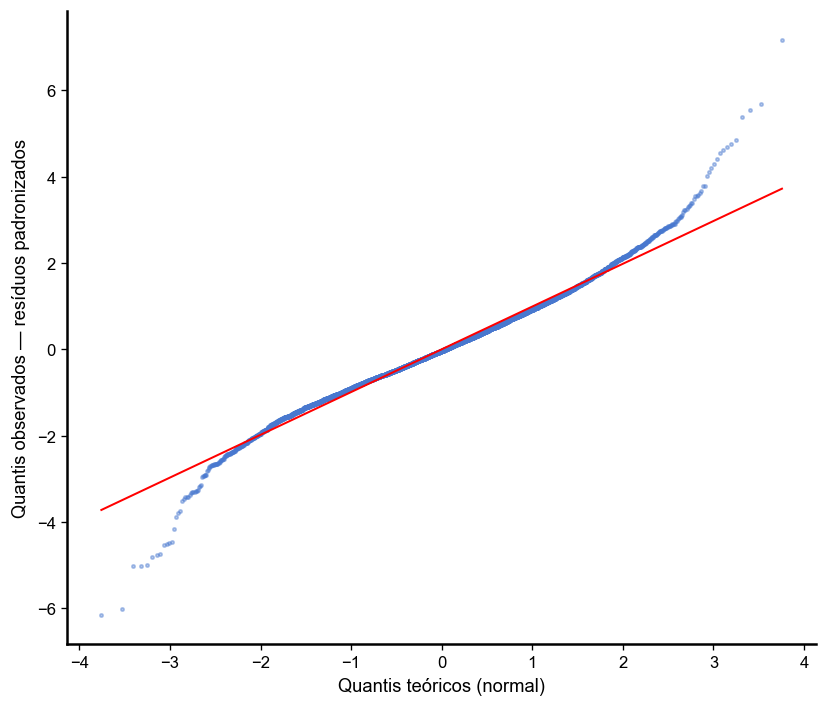

→ Salvo: qqplot_residuos.png


In [14]:
fig, ax = plt.subplots(figsize=(7, 6))
stats.probplot(residuos_std, dist='norm', plot=ax)
ax.get_lines()[0].set(markersize=2, alpha=0.4, color=COR)
ax.get_lines()[1].set(color='red', linewidth=1.2)
ax.set_xlabel('Quantis teóricos (normal)')
ax.set_ylabel('Quantis observados — resíduos padronizados')
for spine in ['top','right']:
    ax.spines[spine].set_visible(False)
for spine in ['left','bottom']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_linewidth(1.5)
    ax.spines[spine].set_color('black')
ax.set_title('')
ax.tick_params(colors='black')
plt.tight_layout()
plt.savefig(os.path.join(SAIDA_DIR, 'qqplot_residuos.png'), bbox_inches='tight', dpi=150)
plt.show()
print('→ Salvo: qqplot_residuos.png')

### 6f. Resíduos vs. valores ajustados

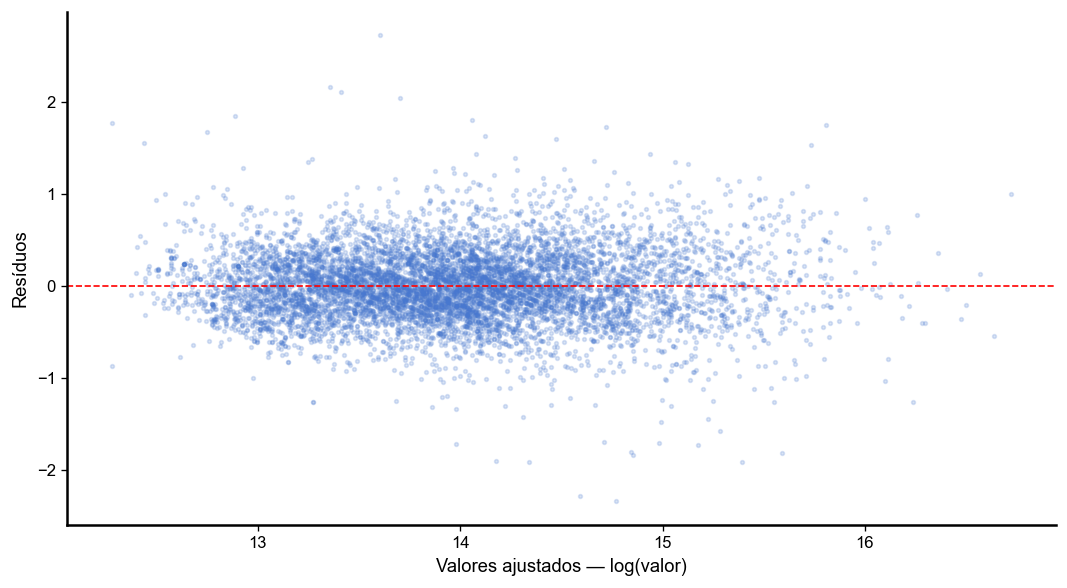

→ Salvo: residuos_vs_ajustados.png


In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(ajustados, residuos, alpha=0.2, s=5, color=COR)
ax.axhline(0, color='red', linewidth=1, linestyle='--')
ax.set_xlabel('Valores ajustados — log(valor)')
ax.set_ylabel('Resíduos')
aplicar_estilo(ax)
plt.tight_layout()
plt.savefig(os.path.join(SAIDA_DIR, 'residuos_vs_ajustados.png'), bbox_inches='tight', dpi=150)
plt.show()
print('→ Salvo: residuos_vs_ajustados.png')

---
## [Extra] Stepwise

In [16]:
try:
    from statstests.process import stepwise as sw_func
    X_step      = sm.add_constant(df_model[PREDS].astype(float))
    y_step      = df_model['log_valor']
    modelo_base = sm.OLS(y_step, X_step).fit()
    try:
        modelo_step = sw_func(modelo_base, pvalue_limit=0.05)
    except TypeError:
        try:
            modelo_step = sw_func(modelo_base, 0.05)
        except TypeError:
            modelo_step = sw_func(modelo_base)
    selecionadas = set(modelo_step.model.exog_names) - {'const', 'Intercept'}
    removidas    = set(PREDS) - selecionadas
    print(f"Variáveis removidas: {', '.join(removidas) or 'nenhuma'}")
    print(f'R² ajustado modelo: {MODELO.rsquared_adj:.4f}')
    print(f'R² ajustado stepwise: {modelo_step.rsquared_adj:.4f}')
    with open(os.path.join(SAIDA_DIR, 'stepwise_summary.txt'), 'w', encoding='utf-8') as f:
        f.write(str(modelo_step.summary()))
    print('→ Salvo: stepwise_summary.txt')
except ImportError:
    print('statstests não instalado: pip install statstests')
except Exception as e:
    print(f'Erro: {e}')

Regression type: OLS 

Estimating model...: 
 log_valor ~ Q('log_tamanho_m2') + Q('quartos') + Q('banheiros') + Q('vagas') + Q('piscina') + Q('sacada') + Q('churrasqueira') + Q('imovel_mobiliado') + Q('elevador') + Q('academia') + Q('salao_de_festas') + Q('regiao_Central') + Q('regiao_Continental') + Q('regiao_Leste') + Q('regiao_Norte') + Q('regiao_Palhoca') + Q('regiao_Sul') + Q('regiao_Sao_Jose') + Q('tipo_Casa')

 Discarding atribute "Q('imovel_mobiliado')" with p-value equal to 0.05410161090230582 

Estimating model...: 
 log_valor ~ Q('log_tamanho_m2') + Q('quartos') + Q('banheiros') + Q('vagas') + Q('piscina') + Q('sacada') + Q('churrasqueira') + Q('elevador') + Q('academia') + Q('salao_de_festas') + Q('regiao_Central') + Q('regiao_Continental') + Q('regiao_Leste') + Q('regiao_Norte') + Q('regiao_Palhoca') + Q('regiao_Sul') + Q('regiao_Sao_Jose') + Q('tipo_Casa')

 No more atributes with p-value higher than 0.05

 Atributes discarded on the process...: 

{'atribute': "Q('imovel_

---
## Relatório final

In [17]:
print('CONCLUÍDO')
print(f'Modelo: {melhor_nome}')
print(f'n={int(MODELO.nobs):,}  R²={MODELO.rsquared_adj:.4f}  F p={MODELO.f_pvalue:.2e}')
print(f"HC3: {'aplicado' if bp_p < 0.05 else 'não necessário'}")
print(f'\nArquivos em: {os.path.abspath(SAIDA_DIR)}')
for arq in sorted(os.listdir(SAIDA_DIR)):
    print(f'  {arq}')

CONCLUÍDO
Modelo: A — original
n=8,056  R²=0.7636  F p=0.00e+00
HC3: aplicado

Arquivos em: c:\Users\gabri\Desktop\scraping_imoveis\ARQUIVOS PARA GITHUB\regressao_output
  coeficientes.csv
  comparacao_especificacoes.csv
  modelo_final_summary.txt
  modelo_hc3_summary.txt
  qqplot_residuos.png
  residuos_vs_ajustados.png
  stepwise_summary.txt
  vif_modelo.csv
